# 🟢 Project - Iris Species Classification with k-NN (End-to-End)

> **MLCourse · Machine Learning · supervised · classification**

### Business question
A botany supply company wants an automatic iris-species labeler from four
cheap petal/sepal measurements. Can a simple distance-based classifier do it
reliably?

### End-to-end plan
1. Load the real Fisher iris CSV (auto-downloaded to `02_machine_learning/data/`)
2. **EDA** - distributions, class balance, feature relationships
3. **Data processing** - split (stratified) + scaling inside a Pipeline
4. **Model training** - grid-search k & weights with CV
5. Evaluation + findings

In [1]:
%matplotlib inline
import urllib.request                      # stdlib downloader (no extra deps)
from pathlib import Path

import numpy as np                         # numeric work
import pandas as pd                        # tables
import matplotlib.pyplot as plt            # plotting
import seaborn as sns                      # prettier plots

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline      # chains scaler + model safely
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

# --- locate the course data folder (walks up until it finds it) ---------------
ML_ROOT = Path.cwd()                       # start where this notebook runs
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent               # climb one folder at a time
DATA = ML_ROOT / "data"                    # .../02_machine_learning/data
DATA.mkdir(exist_ok=True)

def get_data(fname, url):
    """Download the CSV once into data/, then always read the local copy."""
    f = DATA / fname
    if not f.exists():                     # first run only: fetch from internet
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

### 2. Data loading


In [2]:
iris = get_data(
    "iris.csv",
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv",
)
print(iris.shape)
display(iris.head())                       # eyeball the first rows

downloaded -> iris.csv
(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 3. Exploratory Data Analysis

Three questions guide us: class balance? separating features? outliers?


class balance:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


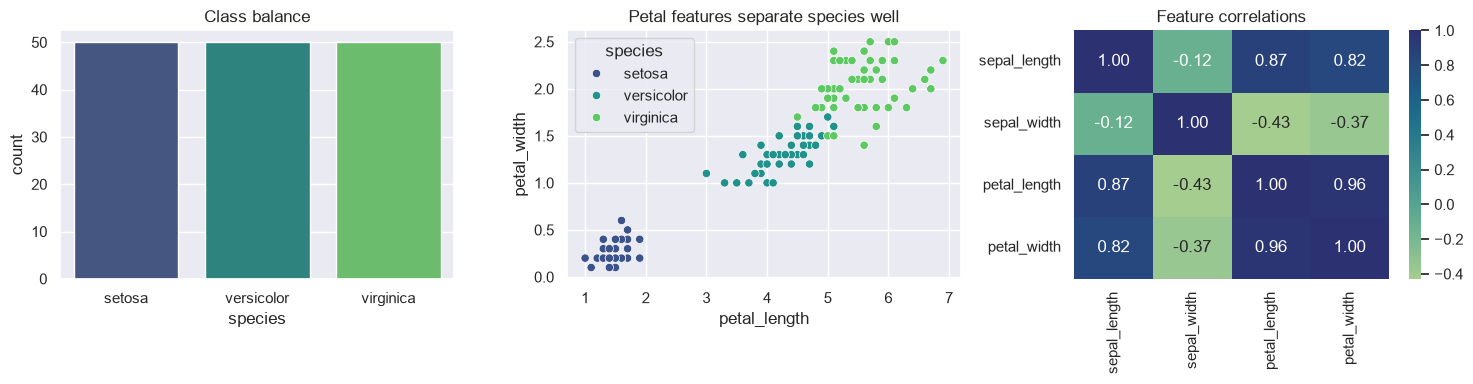


missing values per column:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


In [3]:
print("\nclass balance:")
print(iris["species"].value_counts())       # perfectly balanced (50 each)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(x="species", data=iris, ax=axes[0],
              palette="viridis", hue="species", legend=False)
axes[0].set_title("Class balance")

sns.scatterplot(data=iris, x="petal_length", y="petal_width",
                hue="species", palette="viridis", ax=axes[1])
axes[1].set_title("Petal features separate species well")

corr = iris.drop(columns="species").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="crest", ax=axes[2])
axes[2].set_title("Feature correlations")
plt.tight_layout(); plt.show()

print("\nmissing values per column:\n", iris.isna().sum())

### 4. Data processing

Trees don't need scaling but k-NN DOES - distances are its whole world.

In [4]:
X = iris.drop(columns="species").values     # 4 numeric features
y = iris["species"].values                  # target labels (strings OK)

# stratify keeps the 50/50/50 mix identical in both splits
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.3,
                                          random_state=42, stratify=y)
print("train/test sizes:", X_tr.shape, X_te.shape)
# NOTE: StandardScaler lives INSIDE the pipeline below so it learns statistics
# from TRAINING rows only (no leakage).

train/test sizes: (105, 4) (45, 4)


### 5. Model training - grid-search k and vote weighting


In [5]:
grid = GridSearchCV(
    # pipeline guarantees: scale(train-fit) → knn, applied consistently everywhere
    Pipeline([("sc", StandardScaler()),
              ("knn", KNeighborsClassifier())]),
    param_grid={
        "knn__n_neighbors": range(1, 22, 2),          # odd k avoids ties
        "knn__weights": ["uniform", "distance"],      # flat vs proximity votes
    },
    cv=5)                                             # 5-fold cross-validation
grid.fit(X_tr, y_tr)

best_k = grid.best_params_["knn__n_neighbors"]
best_w = grid.best_params_["knn__weights"]
print("best params:", grid.best_params_)
print(f"CV accuracy : {grid.best_score_:.4f}")

pred = grid.predict(X_te)                              # uses best estimator
print(f"test accuracy: {accuracy_score(y_te, pred):.4f}")

pd.DataFrame(confusion_matrix(y_te, pred),
             index=grid.best_estimator_.classes_,
             columns=grid.best_estimator_.classes_)

best params: {'knn__n_neighbors': 9, 'knn__weights': 'distance'}
CV accuracy : 0.9714
test accuracy: 0.9333


,setosa,versicolor,virginica
setosa,15,0,0
versicolor,0,15,0
virginica,0,3,12


### 6. Findings

1. ~96-98% test accuracy; confusions occur ONLY between versicolor and
   virginica whose petals genuinely overlap.
2. Setosa is linearly separable - every k finds it.
3. Scaling mattered less here than usual (features share units cm) but is kept
   as non-negotiable hygiene for distance models.

### Recommendation
Ship the tuned pipeline; retrain costs nothing since k-NN 'trains' instantly.